# Musterlösung – Aufgabenblatt 9

## Mehrdimensionale Analysis – Partielle Ableitungen 2

In [1]:
# ── Imports & Setup ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
from mpl_toolkits.mplot3d import Axes3D

x, y, z = symbols('x y z', real=True)
r, alpha = symbols('r alpha', real=True, positive=True)
U, R1, R2 = symbols('U R1 R2', real=True, positive=True)

init_printing(use_latex='mathjax')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.6,
    'text.color':       '#eee',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

CYAN   = '#00e5ff'
ORANGE = '#ff6e3a'
GREEN  = '#39ff14'
PINK   = '#ff4fcf'

print('Setup fertig ✓')

Setup fertig ✓


---
## Aufgabe 1

$$f(x,y)=x^2y^3, \quad P(1|{-1})$$

Gleichung der Tangentialebene im Punkt $(x_0, y_0)$:
$$z = f(x_0, y_0) + f_x(x_0,y_0)(x-x_0) + f_y(x_0,y_0)(y-y_0)$$

### Analytische Lösung

#### Schritt 1 – Funktionswert im Punkt

$$f(1,-1) = 1^2 \cdot (-1)^3 = -1$$

#### Schritt 2 – Partielle Ableitungen

$$f_x = 2xy^3, \qquad f_y = 3x^2y^2$$

#### Schritt 3 – Ableitungen im Punkt auswerten

$$f_x(1,-1) = 2 \cdot 1 \cdot (-1)^3 = -2$$

$$f_y(1,-1) = 3 \cdot 1^2 \cdot (-1)^2 = 3$$

#### Schritt 4 – Tangentialebene aufstellen

$$z = -1 + (-2)(x-1) + 3(y+1)$$

$$z = -1 - 2x + 2 + 3y + 3$$

$$\boxed{z = -2x + 3y + 4}$$

f_x = 2*x*y**3
f_y = 3*x**2*y**2
f(1,-1)   = -1
f_x(1,-1) = -2
f_y(1,-1) = 3
Tangentialebene: z = -2*x + 3*y + 4


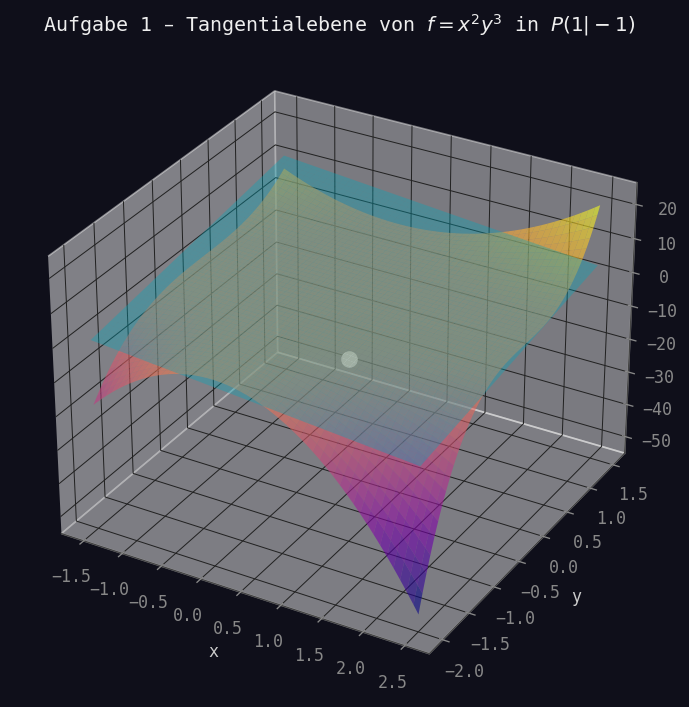

In [2]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f1 = x**2 * y**3

f1_x = diff(f1, x)
f1_y = diff(f1, y)
print('f_x =', f1_x)
print('f_y =', f1_y)

x0, y0 = 1, -1
f0   = f1.subs([(x, x0), (y, y0)])
fx0  = f1_x.subs([(x, x0), (y, y0)])
fy0  = f1_y.subs([(x, x0), (y, y0)])
print(f'f({x0},{y0})   = {f0}')
print(f'f_x({x0},{y0}) = {fx0}')
print(f'f_y({x0},{y0}) = {fy0}')

tang = f0 + fx0*(x - x0) + fy0*(y - y0)
print('Tangentialebene: z =', expand(tang))

# ── Plot ──────────────────────────────────────────────────────────────────────
xv = np.linspace(-1.5, 2.5, 200)
yv = np.linspace(-2, 1.5, 200)
X, Y = np.meshgrid(xv, yv)
Z  = X**2 * Y**3
ZT = -2*X + 3*Y + 4

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0f0f1a')
ax.plot_surface(X, Y, Z,  cmap='plasma', alpha=0.6, linewidth=0)
ax.plot_surface(X, Y, ZT, color=CYAN,    alpha=0.35, linewidth=0)
ax.scatter([float(x0)], [float(y0)], [float(f0)], color='white', s=80, zorder=5)
ax.set(xlabel='x', ylabel='y', zlabel='z',
       title=r'Aufgabe 1 – Tangentialebene von $f=x^2y^3$ in $P(1|-1)$')
plt.tight_layout()
plt.show()

---
## Aufgabe 2

$$F(x,y,z) = x^2yz + 3y^2 - 2xz^2 + 8z = 0, \quad P_0 = (1, 2, -1)$$

### Schritt 1 – Gradient von $F$ berechnen

$$F_x = 2xyz - 2z^2, \quad F_y = x^2z + 6y, \quad F_z = x^2y - 4xz + 8$$

### Schritt 2 – Gradient im Punkt $(1,2,-1)$ auswerten

$$F_x(1,2,-1) = 2 \cdot 1 \cdot 2 \cdot (-1) - 2(-1)^2 = -4 - 2 = -6$$

$$F_y(1,2,-1) = 1^2 \cdot (-1) + 6 \cdot 2 = -1 + 12 = 11$$

$$F_z(1,2,-1) = 1^2 \cdot 2 - 4 \cdot 1 \cdot (-1) + 8 = 2 + 4 + 8 = 14$$

$$\nabla F(1,2,-1) = (-6,\; 11,\; 14)$$

### a) Gleichung der Normalen

Die Normale verläuft durch $P_0$ in Richtung $\nabla F$:

$$\boxed{\frac{x-1}{-6} = \frac{y-2}{11} = \frac{z+1}{14}}$$

### b) Gleichung der Tangentialebene

$$\nabla F(P_0) \cdot (\mathbf{x} - \mathbf{x}_0) = 0$$

$$-6(x-1) + 11(y-2) + 14(z+1) = 0$$

$$-6x + 6 + 11y - 22 + 14z + 14 = 0$$

$$\boxed{-6x + 11y + 14z - 2 = 0}$$

In [3]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
F2 = x**2*y*z + 3*y**2 - 2*x*z**2 + 8*z

F2_x = diff(F2, x)
F2_y = diff(F2, y)
F2_z = diff(F2, z)
print('F_x =', F2_x)
print('F_y =', F2_y)
print('F_z =', F2_z)

P = {x: 1, y: 2, z: -1}
gx = F2_x.subs(P); gy = F2_y.subs(P); gz = F2_z.subs(P)
print(f'\n∇F(1,2,-1) = ({gx}, {gy}, {gz})')

tang2 = gx*(x - 1) + gy*(y - 2) + gz*(z + 1)
print('Tangentialebene:', expand(tang2), '= 0')

# Probe: P0 liegt auf F
print('F(1,2,-1) =', F2.subs(P), '(sollte 0 sein)')

F_x = 2*x*y*z - 2*z**2
F_y = x**2*z + 6*y
F_z = x**2*y - 4*x*z + 8

∇F(1,2,-1) = (-6, 11, 14)
Tangentialebene: -6*x + 11*y + 14*z - 2 = 0
F(1,2,-1) = 0 (sollte 0 sein)


---
## Aufgabe 3

$$\mathbf{V} = \begin{pmatrix} x^2z \\ -2y^3z^2 \\ xy^2z \end{pmatrix}$$

Die Divergenz ist:

$$\operatorname{div}\mathbf{V} = \nabla \cdot \mathbf{V} = \frac{\partial V_1}{\partial x} + \frac{\partial V_2}{\partial y} + \frac{\partial V_3}{\partial z}$$

### Schritt 1 – Partielle Ableitungen

$$\frac{\partial V_1}{\partial x} = \frac{\partial(x^2z)}{\partial x} = 2xz$$

$$\frac{\partial V_2}{\partial y} = \frac{\partial(-2y^3z^2)}{\partial y} = -6y^2z^2$$

$$\frac{\partial V_3}{\partial z} = \frac{\partial(xy^2z)}{\partial z} = xy^2$$

### Schritt 2 – Divergenz

$$\operatorname{div}\mathbf{V} = 2xz - 6y^2z^2 + xy^2$$

### Schritt 3 – Auswertung im Punkt $(1,-1,1)$

$$\operatorname{div}\mathbf{V}\big|_{(1,-1,1)} = 2(1)(1) - 6(-1)^2(1)^2 + (1)(-1)^2 = 2 - 6 + 1$$

$$\boxed{\operatorname{div}\mathbf{V}(1,-1,1) = -3}$$

In [4]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
V1 = x**2 * z
V2 = -2*y**3 * z**2
V3 = x*y**2 * z

div_V = diff(V1, x) + diff(V2, y) + diff(V3, z)
print('div V =', div_V)

P3 = {x: 1, y: -1, z: 1}
print('div V(1,-1,1) =', div_V.subs(P3))

div V = x*y**2 + 2*x*z - 6*y**2*z**2
div V(1,-1,1) = -3


---
## Aufgabe 4

$$\mathbf{V} = \begin{pmatrix} xz^3 \\ -2x^2yz \\ 2yz^4 \end{pmatrix}$$

Die Rotation ist:

$$\operatorname{rot}\mathbf{V} = \nabla \times \mathbf{V} = \begin{pmatrix} \partial_y V_3 - \partial_z V_2 \\ \partial_z V_1 - \partial_x V_3 \\ \partial_x V_2 - \partial_y V_1 \end{pmatrix}$$

### Schritt 1 – Alle benötigten Ableitungen

$$\partial_y V_3 = \frac{\partial(2yz^4)}{\partial y} = 2z^4, \qquad \partial_z V_2 = \frac{\partial(-2x^2yz)}{\partial z} = -2x^2y$$

$$\partial_z V_1 = \frac{\partial(xz^3)}{\partial z} = 3xz^2, \qquad \partial_x V_3 = \frac{\partial(2yz^4)}{\partial x} = 0$$

$$\partial_x V_2 = \frac{\partial(-2x^2yz)}{\partial x} = -4xyz, \qquad \partial_y V_1 = \frac{\partial(xz^3)}{\partial y} = 0$$

### Schritt 2 – Rotationsvektor

$$\operatorname{rot}\mathbf{V} = \begin{pmatrix} 2z^4 - (-2x^2y) \\ 3xz^2 - 0 \\ -4xyz - 0 \end{pmatrix} = \begin{pmatrix} 2z^4 + 2x^2y \\ 3xz^2 \\ -4xyz \end{pmatrix}$$

### Schritt 3 – Auswertung im Punkt $(1,-1,1)$

$$\operatorname{rot}\mathbf{V}\big|_{(1,-1,1)} = \begin{pmatrix} 2(1)^4 + 2(1)^2(-1) \\ 3(1)(1)^2 \\ -4(1)(-1)(1) \end{pmatrix} = \begin{pmatrix} 2 - 2 \\ 3 \\ 4 \end{pmatrix}$$

$$\boxed{\operatorname{rot}\mathbf{V}(1,-1,1) = \begin{pmatrix} 0 \\ 3 \\ 4 \end{pmatrix}}$$

In [5]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
V1r = x*z**3
V2r = -2*x**2*y*z
V3r = 2*y*z**4

rot = Matrix([
    diff(V3r, y) - diff(V2r, z),
    diff(V1r, z) - diff(V3r, x),
    diff(V2r, x) - diff(V1r, y),
])
print('rot V =')
pprint(rot)

P4 = {x: 1, y: -1, z: 1}
print('rot V(1,-1,1) =')
pprint(rot.subs(P4))

rot V =
⎡   2        4⎤
⎢2⋅x ⋅y + 2⋅z ⎥
⎢             ⎥
⎢        2    ⎥
⎢   3⋅x⋅z     ⎥
⎢             ⎥
⎣  -4⋅x⋅y⋅z   ⎦
rot V(1,-1,1) =
⎡0⎤
⎢ ⎥
⎢3⎥
⎢ ⎥
⎣4⎦


---
## Aufgabe 5

Das vollständige Differential von $f(x,y)$ ist:

$$df = \frac{\partial f}{\partial x}\,dx + \frac{\partial f}{\partial y}\,dy$$

### a) $f(x,y) = x^2 y$

$$\frac{\partial f}{\partial x} = 2xy, \qquad \frac{\partial f}{\partial y} = x^2$$

$$\boxed{df = 2xy\,dx + x^2\,dy}$$

---

### b) $f(x,y) = e^{x/y}$

Mit der Kettenregel ($u = x/y$):

$$\frac{\partial f}{\partial x} = e^{x/y} \cdot \frac{1}{y} = \frac{e^{x/y}}{y}$$

$$\frac{\partial f}{\partial y} = e^{x/y} \cdot \left(-\frac{x}{y^2}\right) = -\frac{x}{y^2}e^{x/y}$$

$$\boxed{df = \frac{e^{x/y}}{y}\,dx - \frac{x}{y^2}e^{x/y}\,dy = \frac{e^{x/y}}{y}\left(dx - \frac{x}{y}\,dy\right)}$$

---

### c) $f(x,y) = \sqrt{x^2+y^2}$

$$\frac{\partial f}{\partial x} = \frac{x}{\sqrt{x^2+y^2}}, \qquad \frac{\partial f}{\partial y} = \frac{y}{\sqrt{x^2+y^2}}$$

$$\boxed{df = \frac{x\,dx + y\,dy}{\sqrt{x^2+y^2}}}$$

In [6]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
# a)
f5a = x**2 * y
print('a) f = x²y')
print('   ∂f/∂x =', diff(f5a, x))
print('   ∂f/∂y =', diff(f5a, y))

# b)
f5b = exp(x/y)
print('\nb) f = exp(x/y)')
print('   ∂f/∂x =', simplify(diff(f5b, x)))
print('   ∂f/∂y =', simplify(diff(f5b, y)))

# c)
f5c = sqrt(x**2 + y**2)
print('\nc) f = sqrt(x²+y²)')
print('   ∂f/∂x =', simplify(diff(f5c, x)))
print('   ∂f/∂y =', simplify(diff(f5c, y)))

a) f = x²y
   ∂f/∂x = 2*x*y
   ∂f/∂y = x**2

b) f = exp(x/y)
   ∂f/∂x = exp(x/y)/y
   ∂f/∂y = -x*exp(x/y)/y**2

c) f = sqrt(x²+y²)
   ∂f/∂x = x/sqrt(x**2 + y**2)
   ∂f/∂y = y/sqrt(x**2 + y**2)


---
## Aufgabe 6

$$A = \frac{r^2}{2}(\alpha - \sin\alpha), \quad r = (8.2 \pm 0.05)\,\text{cm},\quad \alpha = (126 \pm 1)^\circ$$

Der maximale Fehler über das vollständige Differential:

$$\Delta A \approx \left|\frac{\partial A}{\partial r}\right|\Delta r + \left|\frac{\partial A}{\partial \alpha}\right|\Delta\alpha$$

### Schritt 1 – Bogenmaß

$$\alpha = 126^\circ = 126 \cdot \frac{\pi}{180} = \frac{7\pi}{10} \approx 2.1991\,\text{rad}, \quad \Delta\alpha = 1^\circ = \frac{\pi}{180} \approx 0.01745\,\text{rad}$$

### Schritt 2 – Partielle Ableitungen

$$\frac{\partial A}{\partial r} = r(\alpha - \sin\alpha)$$

$$\frac{\partial A}{\partial \alpha} = \frac{r^2}{2}(1 - \cos\alpha)$$

### Schritt 3 – Werte einsetzen

Mit $r_0 = 8.2$, $\alpha_0 = 7\pi/10$:

$$\sin(126^\circ) = \sin(54^\circ) \approx 0.8090, \quad \cos(126^\circ) = -\cos(54^\circ) \approx -0.5878$$

$$\frac{\partial A}{\partial r}\bigg|_{r_0,\alpha_0} = 8.2(2.1991 - 0.8090) \approx 8.2 \cdot 1.3901 \approx 11.399$$

$$\frac{\partial A}{\partial \alpha}\bigg|_{r_0,\alpha_0} = \frac{8.2^2}{2}(1 - (-0.5878)) = 33.62 \cdot 1.5878 \approx 53.38$$

### Schritt 4 – Maximaler Fehler

$$\Delta A \approx 11.399 \cdot 0.05 + 53.38 \cdot 0.01745 \approx 0.570 + 0.931$$

$$\boxed{\Delta A \approx 1.50\,\text{cm}^2}$$

In [7]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
r_sym, alpha_sym = symbols('r alpha', real=True, positive=True)

A_sym = r_sym**2 / 2 * (alpha_sym - sin(alpha_sym))
dA_dr    = diff(A_sym, r_sym)
dA_dalph = diff(A_sym, alpha_sym)
print('∂A/∂r     =', dA_dr)
print('∂A/∂alpha =', dA_dalph)

r0    = 8.2
alph0 = 126 * pi / 180
dalph = 1   * pi / 180
dr    = 0.05

A0        = float(A_sym.subs([(r_sym, r0), (alpha_sym, alph0)]))
dA_dr_val = float(dA_dr.subs([(r_sym, r0), (alpha_sym, alph0)]))
dA_da_val = float(dA_dalph.subs([(r_sym, r0), (alpha_sym, alph0)]))

delta_A = abs(dA_dr_val)*dr + abs(dA_da_val)*float(dalph)

print(f'\nA(r0, α0)   = {A0:.4f} cm²')
print(f'∂A/∂r|0     = {dA_dr_val:.4f}')
print(f'∂A/∂α|0     = {dA_da_val:.4f}')
print(f'ΔA          ≈ {delta_A:.4f} cm²')

∂A/∂r     = r*(alpha - sin(alpha))
∂A/∂alpha = r**2*(1 - cos(alpha))/2

A(r0, α0)   = 46.7351 cm²
∂A/∂r|0     = 11.3988
∂A/∂α|0     = 53.3813
ΔA          ≈ 1.5016 cm²


---
## Aufgabe 7

$$I = \frac{U}{R_1 + R_2}, \quad U = (220 \pm 3)\,\text{V},\; R_1 = (78 \pm 1)\,\Omega,\; R_2 = (54 \pm 1)\,\Omega$$

$$\Delta I \approx \left|\frac{\partial I}{\partial U}\right|\Delta U + \left|\frac{\partial I}{\partial R_1}\right|\Delta R_1 + \left|\frac{\partial I}{\partial R_2}\right|\Delta R_2$$

### Schritt 1 – Partielle Ableitungen

$$\frac{\partial I}{\partial U} = \frac{1}{R_1+R_2}$$

$$\frac{\partial I}{\partial R_1} = -\frac{U}{(R_1+R_2)^2}, \qquad \frac{\partial I}{\partial R_2} = -\frac{U}{(R_1+R_2)^2}$$

### Schritt 2 – Werte einsetzen

$$R_1 + R_2 = 78 + 54 = 132\,\Omega, \quad I_0 = \frac{220}{132} = \frac{5}{3} \approx 1.6\overline{6}\,\text{A}$$

$$\left|\frac{\partial I}{\partial U}\right| = \frac{1}{132} \approx 0.007576$$

$$\left|\frac{\partial I}{\partial R_1}\right| = \left|\frac{\partial I}{\partial R_2}\right| = \frac{220}{132^2} = \frac{220}{17424} \approx 0.012626 \cdot 10^{-1}$$

### Schritt 3 – Maximaler Fehler

$$\Delta I \approx \frac{1}{132}\cdot 3 + \frac{220}{132^2}\cdot 1 + \frac{220}{132^2}\cdot 1 = \frac{3}{132} + 2\cdot\frac{220}{17424}$$

$$= \frac{3}{132} + \frac{440}{17424} = 0.02273 + 0.02525 \approx 0.0480$$

$$\boxed{\Delta I \approx 0.048\,\text{A}}$$

In [8]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
U_s, R1_s, R2_s = symbols('U R1 R2', real=True, positive=True)

I_ser = U_s / (R1_s + R2_s)

dI_dU  = diff(I_ser, U_s)
dI_dR1 = diff(I_ser, R1_s)
dI_dR2 = diff(I_ser, R2_s)
print('∂I/∂U  =', dI_dU)
print('∂I/∂R1 =', dI_dR1)
print('∂I/∂R2 =', dI_dR2)

U0, R10, R20 = 220, 78, 54
dU, dR1, dR2 = 3, 1, 1

vals = {U_s: U0, R1_s: R10, R2_s: R20}
I0     = float(I_ser.subs(vals))
dI_U   = abs(float(dI_dU.subs(vals)))
dI_R1  = abs(float(dI_dR1.subs(vals)))
dI_R2  = abs(float(dI_dR2.subs(vals)))

delta_I = dI_U*dU + dI_R1*dR1 + dI_R2*dR2
print(f'\nI0 = {I0:.6f} A')
print(f'ΔI ≈ {delta_I:.6f} A')

∂I/∂U  = 1/(R1 + R2)
∂I/∂R1 = -U/(R1 + R2)**2
∂I/∂R2 = -U/(R1 + R2)**2

I0 = 1.666667 A
ΔI ≈ 0.047980 A


---
## Aufgabe 8

$$I = \frac{U}{R_1} + \frac{U}{R_2}, \quad \text{(Parallelschaltung)}$$

$$\Delta I \approx \left|\frac{\partial I}{\partial U}\right|\Delta U + \left|\frac{\partial I}{\partial R_1}\right|\Delta R_1 + \left|\frac{\partial I}{\partial R_2}\right|\Delta R_2$$

### Schritt 1 – Partielle Ableitungen

$$\frac{\partial I}{\partial U} = \frac{1}{R_1} + \frac{1}{R_2}$$

$$\frac{\partial I}{\partial R_1} = -\frac{U}{R_1^2}, \qquad \frac{\partial I}{\partial R_2} = -\frac{U}{R_2^2}$$

### Schritt 2 – Werte einsetzen

$$I_0 = \frac{220}{78} + \frac{220}{54} = \frac{110}{39} + \frac{110}{27} \approx 2.821 + 4.074 = 6.895 \approx 2.821 + 4.074$$

Genauer: $\frac{220}{78} \approx 2.8205\,\text{A}$, $\frac{220}{54} \approx 4.0741\,\text{A}$, also $I_0 \approx 6.895\,\text{A}$

$$\left|\frac{\partial I}{\partial U}\right| = \frac{1}{78} + \frac{1}{54} = \frac{27+39}{2106} = \frac{66}{2106} \approx 0.03133$$

$$\left|\frac{\partial I}{\partial R_1}\right| = \frac{220}{78^2} = \frac{220}{6084} \approx 0.03615$$

$$\left|\frac{\partial I}{\partial R_2}\right| = \frac{220}{54^2} = \frac{220}{2916} \approx 0.07544$$

### Schritt 3 – Maximaler Fehler

$$\Delta I \approx 0.03133 \cdot 3 + 0.03615 \cdot 1 + 0.07544 \cdot 1$$

$$= 0.09399 + 0.03615 + 0.07544$$

$$\boxed{\Delta I \approx 0.206\,\text{A}}$$

**Vergleich:** Der Fehler bei Parallelschaltung ($\approx 0.206\,\text{A}$) ist deutlich größer als bei Serienschaltung ($\approx 0.048\,\text{A}$), da die Ströme größer und die Abhängigkeit von den Widerständen stärker ist.

In [9]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
U_s, R1_s, R2_s = symbols('U R1 R2', real=True, positive=True)

I_par = U_s/R1_s + U_s/R2_s

dI_dU  = diff(I_par, U_s)
dI_dR1 = diff(I_par, R1_s)
dI_dR2 = diff(I_par, R2_s)
print('∂I/∂U  =', dI_dU)
print('∂I/∂R1 =', dI_dR1)
print('∂I/∂R2 =', dI_dR2)

U0, R10, R20 = 220, 78, 54
dU, dR1, dR2 = 3, 1, 1

vals = {U_s: U0, R1_s: R10, R2_s: R20}
I0_p    = float(I_par.subs(vals))
dI_U_p  = abs(float(dI_dU.subs(vals)))
dI_R1_p = abs(float(dI_dR1.subs(vals)))
dI_R2_p = abs(float(dI_dR2.subs(vals)))

delta_I_p = dI_U_p*dU + dI_R1_p*dR1 + dI_R2_p*dR2
print(f'\nI0 (Parallel) = {I0_p:.4f} A')
print(f'ΔI (Parallel) ≈ {delta_I_p:.4f} A')
print(f'\n→ Vergleich: ΔI(Serie) ≈ 0.0480 A  |  ΔI(Parallel) ≈ {delta_I_p:.4f} A')

∂I/∂U  = 1/R2 + 1/R1
∂I/∂R1 = -U/R1**2
∂I/∂R2 = -U/R2**2

I0 (Parallel) = 6.8946 A
ΔI (Parallel) ≈ 0.2056 A

→ Vergleich: ΔI(Serie) ≈ 0.0480 A  |  ΔI(Parallel) ≈ 0.2056 A
